In [ ]:
# ========= CONFIG (fill locally; do NOT commit secrets) =========
# Tip: use environment variables or a local `.env` file.
# Example:
#   import os
#   OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
#   HF_TOKEN = os.getenv("HF_TOKEN", "")
# ===============================================================



# Enabling the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

[Reference](https://colab.research.google.com/notebooks/gpu.ipynb)

# **Installing BERTopic**

We start by installing BERTopic from PyPi:

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

## Restart the Notebook
After installing BERTopic, some packages that were already loaded were updated and in order to correctly use them, we should now restart the notebook.

From the Menu:

Runtime → Restart Runtime

# Access the filtered, aka complete dataset


In [ ]:
import pandas as pd
from google.colab import drive
import os

# Parameters for dataset
sector = 'camera'
# sector = 'robotics'
# sector = 'semiconductor chips'
# sector = 'mobile_phone'
dataset = 'complete'

# Navigate the folder location
drive.mount("/content/drive")
folder_path = f"/content/drive/MyDrive/TechShiftProject/{sector}/{dataset}_data/"

# Load the csv file
df = pd.read_csv(f"{folder_path}df_id_year_document.csv")

print(len(df))

# Count the number of rows per unique year
year_counts = df['year'].value_counts().sort_index()

# Print the results to determine the start year and end yaer
for year, count in year_counts.items():
    print(f"Year: {year}, Count: {count}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1457933
Year: 1900.0, Count: 6
Year: 1901.0, Count: 14
Year: 1902.0, Count: 12
Year: 1903.0, Count: 15
Year: 1904.0, Count: 21
Year: 1905.0, Count: 14
Year: 1906.0, Count: 8
Year: 1907.0, Count: 8
Year: 1908.0, Count: 19
Year: 1909.0, Count: 23
Year: 1910.0, Count: 8
Year: 1911.0, Count: 9
Year: 1912.0, Count: 12
Year: 1913.0, Count: 16
Year: 1914.0, Count: 15
Year: 1915.0, Count: 20
Year: 1916.0, Count: 26
Year: 1917.0, Count: 46
Year: 1918.0, Count: 53
Year: 1919.0, Count: 19
Year: 1920.0, Count: 19
Year: 1921.0, Count: 36
Year: 1922.0, Count: 35
Year: 1923.0, Count: 55
Year: 1924.0, Count: 40
Year: 1925.0, Count: 44
Year: 1926.0, Count: 60
Year: 1927.0, Count: 52
Year: 1928.0, Count: 72
Year: 1929.0, Count: 80
Year: 1930.0, Count: 142
Year: 1931.0, Count: 248
Year: 1932.0, Count: 271
Year: 1933.0, Count: 274
Year: 1934.0, Count: 282
Year: 1935.0, Count: 29

In [ ]:
# Choose the start year and end year
# Camera
start_year = 1930
end_year = 2023    # the year to end

# # Robotics
# start_year = 1975
# end_year = 2024    # the year to end

# # Semi
# start_year = 1965
# end_year = 2024

# # Mobile Phone
# start_year = 1962
# end_year = 2024

# Filter out all rows earlier than start_year
df = df[(df["year"] >= start_year) & (df["year"] <= end_year)]
df.reset_index(drop=True, inplace=True)

# Convert only float entries in 'document' column to strings
df['document'] = df['document'].apply(lambda x: str(x) if isinstance(x, float) else x)

# Extract contents to train on and corresponding ids
contents = df["document"]
ids = df["id"]

# Display the first content
print(len(contents))
print(contents[0])

# Choose the size of minimum cluster
# Camera
min_cluster_size = 1000    # The larger the cluster size, the fewer the topics
# Others
# min_cluster_size = 500    # The larger the cluster size, the fewer the topics

# Prepare folders for further analysis
if dataset not in ("sampled", "test"):
    embedding_path = f'{folder_path}embedding_analysis_end_{end_year}/'
    bertopic_path = f"{folder_path}/bertopic_model_saved_{min_cluster_size}_end_{end_year}/"
    comprehensive_path = f"{folder_path}/comprehensive_{min_cluster_size}_end_{end_year}/"
else:
    embedding_path = f'{folder_path}embedding_analysis_{constant_patent_num}_{i_sampling}_end_{end_year}/'
    bertopic_path = f"{folder_path}/bertopic_model_saved_{min_cluster_size}_{constant_patent_num}_{i_sampling}_end_{end_year}/"
    comprehensive_path = f"{folder_path}/comprehensive_{min_cluster_size}_{constant_patent_num}_{i_sampling}_end_{end_year}/"

if not os.path.exists(embedding_path):
    os.makedirs(embedding_path)
if not os.path.exists(bertopic_path):
    os.makedirs(bertopic_path)
if not os.path.exists(comprehensive_path):
    os.makedirs(comprehensive_path)

1457076
Keyboard switch  keyboard switch abstract keyboard switch use membrane switch array provide tactile feeling optionally click sound comprises housing positioned membrane switch array plunger reciprocally mounted within housing projects outwardly housing plunger cam portion actuating arm pivoted housing first portion extending beneath plunger second cam follower portion engages cam portion plunger first portion actuating arm boss surface facing away plunger engaging switch array plunger spring housing actuating arm leaf portion 141 first flexes mounted normally outwardly point position providing rest snaps sound switch tactile thereby urge


**Calculate embedding**

In [ ]:
from sentence_transformers import SentenceTransformer

# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(contents, show_progress_bar=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/23487 [00:00<?, ?it/s]

In [ ]:
import pickle

# Save the embeddings
with open(f"{embedding_path}embeddings.pkl", "wb") as f:
    pickle.dump(embeddings, f)

# import numpy as np
# # Round each number in the list of lists to 4 decimal places
# embeddings = np.round(np.array(embeddings, dtype=np.float32), 4)
# print('Embeddings rounded to 4 decimal places')

# # Save the rounded embeddings
# with open(f"{embedding_path}embeddings_rounded.pkl", "wb") as f:
#     pickle.dump(embeddings, f)

Import emebddings

In [ ]:
import pickle

# Load the embeddings
with open(f"{embedding_path}embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

Train the model

In [ ]:
from umap import UMAP

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

from hdbscan import HDBSCAN
hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=True, core_dist_n_jobs=1)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
stop_words = text.ENGLISH_STOP_WORDS.union(['first', 'second', 'third', 'sb', 'thereof', 'include',
                                            'method', 'including', 'includes', 'solve', 'solved', 'solution',
                                            'jpo', 'inpit', 'ncip', 'copyright', 'problem', 'invention',
                                            'innovation', 'provide', 'provides', 'provided', 'following',
                                            'result', 'describe', 'wherein', 'left', 'right', 'purpose', 'constitution',
                                            'january', 'jan', 'february', 'feb', 'march', 'mar', 'april', 'may', 'june',
                                            'july', 'august', 'aug', 'september', 'sep', 'october', 'oct', 'november', 'nov',
                                            'december', 'dec', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday',
                                            'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
                                            'eleven', 'twelve', 'thirteen', 'fourteen', 'fifteen', 'sixteen', 'seventeen',
                                            'eighteen', 'nineteen', 'twenty', 'thirty', 'forty', 'fifty', 'sixty',
                                            'seventy', 'eighty', 'ninety', 'hundred'])
stop_words = list(stop_words)
vectorizer_model = CountVectorizer(stop_words=stop_words, min_df=2, ngram_range=(1, 2))


Choose representation

In [ ]:
# import openai
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech

# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm")

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

# GPT-3.5
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
# client = openai.OpenAI(api_key=""  # TODO: fill in (do not commit))
# openai_model = OpenAI(client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model
}

# Training

In [ ]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
from bertopic import BERTopic

topic_model = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True,
  calculate_probabilities=True
)

topics, probs = topic_model.fit_transform(contents, embeddings)

# Save the model instantly after the training
topic_model.save(bertopic_path, serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

# Save the results of topic modelling to csv
df["topic"] = topics
# probs = [[round(prob, 4) for prob in sublist] for sublist in probs]
df["probs"] = probs.tolist()    # round probs to 4 decimal places


# Save a year id topic csv for later use
df_id_date_topic = df.drop(columns=['document', 'probs'])
df_id_date_topic.to_csv(f'{bertopic_path}df_id_year_topic.csv', index=False)

# Get topic infomation
df_topic_info = topic_model.get_topic_info()
print(f'Number of topics: {len(df_topic_info)}')
df_topic_info.to_csv(f'{bertopic_path}topic_info.csv', index=False)

# Save the full dataframe excluding documnets to the csv file
df = df.drop(columns=['document'])
df.to_csv(f'{bertopic_path}topic_probs_matrix.csv', index=False)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2025-05-08 15:21:54,135 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-08 15:44:49,211 - BERTopic - Dimensionality - Completed ✓
2025-05-08 15:44:49,230 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-08 16:04:41,641 - BERTopic - Cluster - Completed ✓
2025-05-08 16:04:41,774 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-08 16:08:00,715 - BERTopic - Representation - Completed ✓


Number of topics: 88


## **Visualize Topics**

Intertopic distance map

In [ ]:
topic_model.visualize_topics(custom_labels=True)

Hierarchical Clustering

In [ ]:
topic_model.visualize_hierarchy(custom_labels=True)

Visualize topics on a 2-D map

In [ ]:
# Reduce dimensionality of embeddings, this step is optional but much faster to perform iteratively:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

In [ ]:
# Visualize the documents in 2-dimensional space and show the titles on hover instead of the abstracts
# NOTE: You can hide the hover with `hide_document_hover=True` which is especially helpful if you have a large dataset
topic_model.visualize_documents(contents, reduced_embeddings=reduced_embeddings, custom_labels=True)

In [ ]:
# We can also hide the annotation to have a more clear overview of the topics
topic_model.visualize_documents(contents, reduced_embeddings=reduced_embeddings, custom_labels=True, hide_annotations=True)

Output hidden; open in https://colab.research.google.com to view.

# Get indicators of technological shifts


Calculate avg_ and sum_vector

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
import ast
import pickle

sys.path.append('/content/drive/MyDrive/TechShiftProject')
from basic_func import *

# Load CSV and parse stringified vectors
print("Loading topic_probs_matrix.csv...")
df = pd.read_csv(f'{bertopic_path}topic_probs_matrix.csv')
df['probs'] = df['probs'].apply(ast.literal_eval)
print("CSV loaded and 'probs' column parsed.")

# Compute average and sum vectors
print("Computing average and sum topic vectors...")
avg_vectors_raw = df.groupby('year')['probs'].apply(lambda x: np.mean(np.vstack(x), axis=0)).reset_index()
sum_vectors_raw = df.groupby('year')['probs'].apply(lambda x: np.sum(np.vstack(x), axis=0)).reset_index()

# Expand vectors into topic columns
print("Expanding topic vectors into columns...")
num_topics = len(avg_vectors_raw['probs'].iloc[0])
avg_vectors = pd.concat([
    avg_vectors_raw[['year']],
    pd.DataFrame(avg_vectors_raw['probs'].tolist(), columns=[f'topic_{i}' for i in range(num_topics)])
], axis=1)

sum_vectors = pd.concat([
    sum_vectors_raw[['year']],
    pd.DataFrame(sum_vectors_raw['probs'].tolist(), columns=[f'topic_{i}' for i in range(num_topics)])
], axis=1)

# Save the processed vectors
avg_vectors.to_pickle(f"{bertopic_path}avg_vectors.pkl")
sum_vectors.to_pickle(f"{bertopic_path}sum_vectors.pkl")
print("Saved avg_vectors.pkl and sum_vectors.pkl.")

Loading topic_probs_matrix.csv...
CSV loaded and 'probs' column parsed.
Computing average and sum topic vectors...
Expanding topic vectors into columns...
Saved avg_vectors.pkl and sum_vectors.pkl.


Calculation for the trends

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
import ast

sys.path.append('/content/drive/MyDrive/TechShiftProject')
from basic_func import *
import pickle

# Load avg_vectors from the pickle file
avg_vectors = pd.read_pickle(f"{bertopic_path}avg_vectors.pkl")

# Normalize topic weights
print("Normalizing topic weights...")
topic_columns = [col for col in avg_vectors.columns if col.startswith('topic_')]
normalized_weights = avg_vectors[topic_columns].div(avg_vectors[topic_columns].sum(axis=1), axis=0)
normalized_avg_vectors = pd.concat([avg_vectors[['year']], normalized_weights], axis=1)

# Reorder topics and convert to matrix
print("Reordering topics and generating matrix...")
normalized_avg_vectors_sorted = reorder_topics_by_weighted_mean_year(normalized_avg_vectors, reverse_order=False)
normalized_avg_vector_matrix = transform_avg_vector(normalized_avg_vectors_sorted)
normalized_avg_vector_matrix = insert_missing_years(normalized_avg_vector_matrix, start_year, end_year)

# Build index map for synthetic sampling
items = normalized_avg_vector_matrix.index.tolist()
item_indices = {item: i + 1 for i, item in enumerate(items)}

# Generate synthetic samples to compute medians
max_window_size = 5    # The windows size to compute moving average

print("Generating synthetic samples and computing medians...")
samples_by_year = []
medians = []
for column in normalized_avg_vector_matrix.columns:
    year_sample = []
    for item, weight in normalized_avg_vector_matrix[column].items():
        count = int(weight * 100)
        year_sample.extend([item_indices[item]] * count)
    samples_by_year.append(year_sample)
    medians.append(np.median(year_sample))

medians = np.array(medians)
rate_of_change_median = np.diff(medians)
ave_rate_of_change_median = flexible_moving_average(rate_of_change_median, max_window_size)

# Compute weighted means
print("Computing weighted means...")
means = []
for col in normalized_avg_vector_matrix.columns:
    mean = sum(i * weight for i, weight in enumerate(normalized_avg_vector_matrix[col]))
    means.append(mean)

means = np.array(means)
rate_of_change_mean = np.diff(means)
ave_rate_of_change_mean= flexible_moving_average(rate_of_change_mean, max_window_size)

# Compute angle differences
print("Computing angle differences...")
angle_differences = list(compute_angle_differences(normalized_avg_vector_matrix))
ave_angle_differences = flexible_moving_average(angle_differences, max_window_size)

# Compute Gini coefficient of distribution by year
# Initialize an empty list to store Gini coefficients
gini_coefficients = []

# Iterate over each year (column) in the DataFrame
for year in normalized_avg_vector_matrix.columns:
    # Extract the topic distribution for the year as a numpy array
    year_distribution = normalized_avg_vector_matrix[year].to_numpy()
    # Compute the Gini coefficient for the year's distribution
    gini_value = gini_coefficient(year_distribution)
    # Append the Gini coefficient to the list
    gini_coefficients.append(gini_value)

ave_gini_coefficients = flexible_moving_average(gini_coefficients, max_window_size)

# Get year list and topic count for this window
years = np.arange(start_year + 1, end_year + 1)

Normalizing topic weights...
Reordering topics and generating matrix...
Generating synthetic samples and computing medians...
Computing weighted means...
Computing angle differences...


Tech shifts for camera industry

In [ ]:
# Tech shift intensity for camera industry
events = [
    # 1925,          # Leica I introduced
    1936,          # First 35mm SLR camera
    1947,          # Polaroid instant photo system
    1948,          # First 35mm SLR with pentaprism
    (1952, 1959),  # Japanese firms enter SLR market
    1959,          # Fully automatic exposure control
    1975,          # First portable digital camera
    1977,          # First mass-produced autofocus camera
    1978,          # First autofocus SLR
    1978,          # First program auto-exposure SLR
    1981,          # Mavica prototyped
    1987,          # EOS system introduced
    1988,          # First fully digital still camera
    1993,          # CMOS active-pixel sensors created
    1993,          # First digital camera with non-volatile flash memory
    1994,          # CompactFlash cards introduced
    1995,          # Consumer digital with LCD
    1995,          # First interchangeable SLR lens with image stabilization
    (1999, 2000),  # Kyocera VP-210 and Sharp J-SH04 camera phone launched
    2004,          # First mirrorless camera
    2005,          # Face-Priority AF introduced
    2008,          # First Micro Four-Thirds camera launched
    2009           # Smartphone HDR photography introduced
]

Tech shifts for robotics industry

In [ ]:
events = [
    # 1951,          # Cybernetic tortoises learn from experience
    # (1954, 1961),  # The re-programmable industrial arm arrives
    # 1959,          # Computers and machine tools converge
    # (1966, 1970),  # Shakey shows robots can reason
    # 1969,          # The Stanford all-electric arm
    # 1970,          # Robots leave Earth
    # 1972,          # First full-scale humanoid
    # (1973, 1974),  # Microprocessors hit the shop-floor
    1978,          # SCARA revolutionises electronics lines
    1979,          # Stereo-vision navigation
    1985,          # Surgical robots reach the OR
    1986,          # Reactive ‘subsumption’ control
    1995,          # ‘No Hands Across America’
    1997,          # Deep Blue beats a world champion
    1998,          # LEGO Mindstorms democratise robotics
    1999,          # AIBO brings autonomous pets to market
    2000,          # Friendly humanoid & surgical gold standard
    2001,          # Robots for danger and distance
    2002,          # Roomba turns cleaning into a robot service
    (2004, 2005),  # DARPA Grand Challenge births modern AVs
    2007,          # ROS makes robot software open and modular
    2010,          # $150 depth cameras give robots 3-D sight
    (2010, 2019),  # Safe cobots share workspaces
    2014,          # Amazon’s Kiva fleets show cloud-orchestrated swarms
    2016,          # Deep learning supercharges robot perception
    2018,          # Robots hit streets and go viral
    2021,          # Ingenuity’s powered flight on Mars
    2022,          # Foundation-model brains and humanoid bets
    (2023, 2025)   # Robots gain GPT-level reasoning and shared learning
]

Tech shifts for semiconductor chip industry

In [ ]:
events = [
    # 1951,  # Early 1950s: Germanium Transistors, specifically noted as 1951
    # 1955,  # Mid-1950s: Transition to Silicon Transistors, approximated as 1955
    # (1959, 1961),  # 1959-1961: Planar Process and Integrated Circuits
    1965,  # 1965: Integrated-Circuit Minicomputer (DEC PDP-8)
    1968,  # 1968: Introduction of Semiconductor Memory (DRAM)
    1970,  # Early 1970s: MOS Integrated Circuits, approximated as 1970
    1971,  # 1971: Microprocessor (Intel 4004)
    1975,  # Mid-1970s: CMOS Technology, approximated as 1975
    (1973, 1983),  # 1973-1983: VLSI DRAM Step-Jumps (1K to 64K)
    1985,  # Mid-1980s: Application-Specific Integrated Circuits (ASICs), approximated as 1985
    1987,  # 1987: Birth of the Pure-Play Foundry (TSMC)
    (1990, 1993),  # 1990-1993: 4M and 16M DRAM Generations
    1994,  # 1994: Semiconductor Technology Roadmap (SIA/ITRS)
    1995,  # 1995: East-Asian DRAM Ascendancy
    1995,  # Mid-1990s: Application-Specific Standard Products (ASSPs), approximated as 1995
    1999,  # Late 1990s: System-on-Chip (SoC), approximated as 1999
    2005,  # 2005: Multi-Core Processors
    2007,  # 2007: GPU Computing and GPGPU
    2011,  # 2011: 3D FinFET Transistors
    2012,  # 2012: 2.5D Chip Integration
    2012,  # 2012: ‘More-than-Moore’ and ‘Beyond-CMOS’ in ITRS
    2013,  # 2013: 3D NAND Flash Memory
    2015,  # 2015: Domain-Specific AI Accelerators (TPU)
    2015,  # 2015: RISC-V Foundation Formed
    2017,  # 2017: Chiplet-Based Modular Processors
    2018,  # 2018: 3D Logic Stacking (Foveros)
    2019,  # 2019: EUV Lithography in High-Volume Manufacturing
    2022   # 2022: Gate-All-Around (GAA) Transistors
]

Tech shifts for mobile phone industry

In [ ]:
events  = []

Plot the trends

<ipython-input-18-8c84d87192ad>:73: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax2.plot(years[:-1], ave_angle_differences, 'b-', label='Angle Difference', marker='.', color='green')


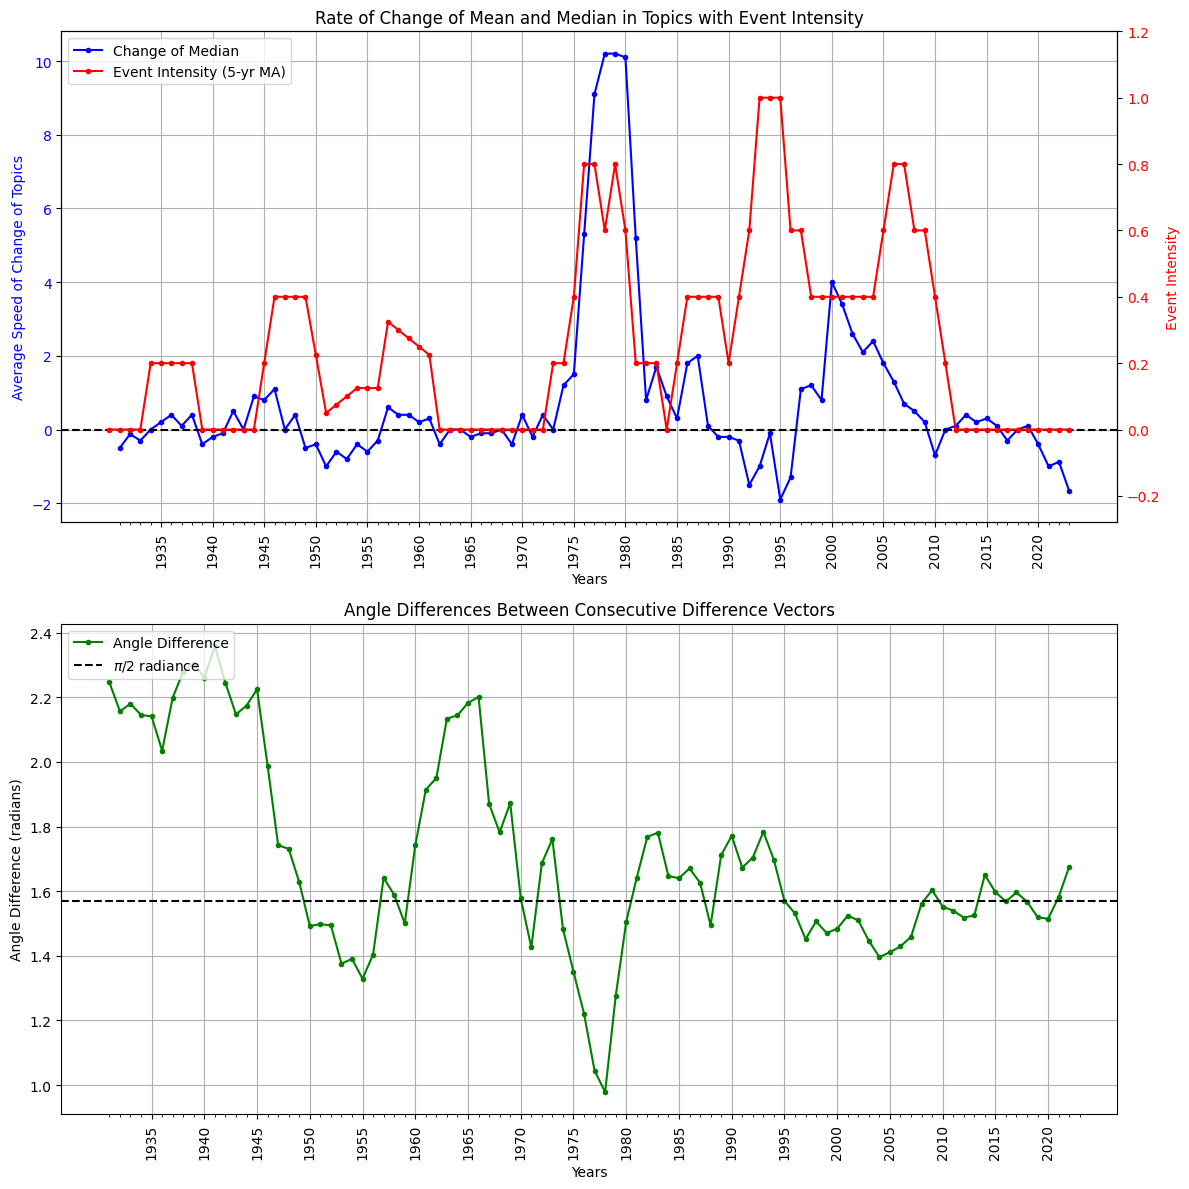

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('/content/drive/MyDrive/TechShiftProject')
from basic_func import *

# Initialize intensity array for years (from start_year to end_year)
years_intensity = np.arange(start_year, end_year + 1)
intensity = np.zeros(len(years_intensity))

# Process each event to compute intensity
for event in events:
    if isinstance(event, int):
        # Single-year event: add 1 to the corresponding year
        idx = event - start_year
        if 0 <= idx < len(intensity):
            intensity[idx] += 1
    else:
        # Year-range event: distribute 1/n across the range
        start, end = event
        n_years = end - start + 1
        weight = 1 / n_years
        for year in range(start, end + 1):
            idx = year - start_year
            if 0 <= idx < len(intensity):
                intensity[idx] += weight

# Compute 5-year moving average for intensity
max_window = 5
ave_intensity = flexible_moving_average(intensity, max_window)

# Prepare the plot configuration
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

# Define major years for labeling (assuming 'years' is defined)
major_years = [year for year in years if year % 5 == 0]

# Top subplot: Rate of change of mean and median
ax1.set_title("Rate of Change of Mean and Median in Topics with Event Intensity")
ax1.set_xlabel("Years")
ax1.grid(True)
ax1.plot(years, ave_rate_of_change_median, label='Change of Median', marker='.', color='blue')
# ax1.plot(years, ave_rate_of_change_mean, label='Change of Mean', marker='.', color='orange')
ax1.set_ylabel('Average Speed of Change of Topics', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.axhline(0, ls='--', color='k')
ax1.set_xticks(major_years)
ax1.set_xticklabels([str(year) for year in major_years], rotation=90)
ax1.set_xticks(years, minor=True)

# Create secondary y-axis for event intensity
ax1_right = ax1.twinx()
ax1_right.plot(np.append(start_year, years), ave_intensity, label='Event Intensity (5-yr MA)', marker='.', color='red')
ax1_right.set_ylabel('Event Intensity', color='red')
ax1_right.tick_params(axis='y', labelcolor='red')

# Align the zero levels of ax1 and ax1_right
ylim_left = ax1.get_ylim()
zero_pos = (0 - ylim_left[0]) / (ylim_left[1] - ylim_left[0])
max_right = max(ave_intensity) * 1.2
if zero_pos != 0 and zero_pos != 1:
    min_right = (zero_pos * max_right) / (zero_pos - 1)
else:
    min_right = min(intensity_ma) * 1.2  # Note: 'intensity_ma' might be a typo; should be 'ave_intensity'?
ax1_right.set_ylim(min_right, max_right)

# Combine legends from ax1 and ax1_right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Bottom subplot: Angle differences
ax2.plot(years[:-1], ave_angle_differences, 'b-', label='Angle Difference', marker='.', color='green')
ax2.axhline(y=np.pi/2, color='black', linestyle='--', label=r'$\pi/2$ radiance')
ax2.set_xticks(major_years)
ax2.set_xticklabels([str(year) for year in major_years], rotation=90)
ax2.set_xticks(years, minor=True)
ax2.grid(True)
ax2.set_xlabel("Years")
ax2.set_ylabel("Angle Difference (radians)")
ax2.set_title("Angle Differences Between Consecutive Difference Vectors")
ax2.legend(loc='upper left')

# # Secondary y-axis for ax2: Gini coefficients
# ax3 = ax2.twinx()
# ax3.plot(np.append(start_year, years), gini_coefficients, 'r-', label='Gini Coefficient', marker='.')
# ax3.set_ylabel("Gini Coefficient", color='red')
# ax3.tick_params(axis='y', labelcolor='red')
# ax3.legend(loc='upper right')

# Adjust layout and save
plt.tight_layout()
plt.savefig(f'{bertopic_path}explicit_change_of_average_shifting_rate_with_three_phase.png', bbox_inches='tight')
plt.show()
